# Paper figure: autoencoder latent CVs and p-ratio organization

This notebook is AE-only. It trains/loads one cached autoencoder for each dataset, encodes held-out trajectories, and makes paper-oriented plots showing that the two latent CVs organize trajectories by p-ratio. The default setting trains on one network per dataset and evaluates all held-out networks.

In [19]:
%matplotlib inline

import os
import sys
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "module://matplotlib_inline.backend_inline")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "lss").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import Normalize

from lss.latent.analysis import framewise_latent_descriptor_sweep, pearson_r, r2_score
from lss.latent.training import encode_reference_context
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.plotting import PAPER_COLORS, apply_editorial_style, style_axes
from lss.utils import resolve_device

apply_editorial_style()
DEVICE = resolve_device("auto")
DEVICE

'cuda'

## Settings

Use `FORCE_TRAIN=True` only when you intentionally want to overwrite the cached AE models.

In [20]:
BASE_SEED = 6545
FORCE_TRAIN = False

TRAIN_COUNT = 1
VAL_COUNT = 20
LATENT_DIM = 2
LATENT_TOKENS = 32
HIDDEN_SIZE = 96
AUTOENCODER_MODEL = "attention"

AE_TRAIN_FRAMES = 100
AE_MAX_EPOCHS = 120
AE_PATIENCE = 10
FRAME_STRIDE = 1
MAX_ANALYSIS_FRAMES_PER_SIM = 100

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "results" / "05_paper_autoencoder_cvs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CASES = {
    "depablo_low_temp": {
        "dataset_name": "depablo_low_temp",
        "label": "dePablo low temperature",
        "path": PROJECT_ROOT / "data" / "depablo-near-zero-temp.pt",
    },
    "reid": {
        "dataset_name": "reid",
        "label": "Reid",
        "path": PROJECT_ROOT / "data" / "reid_200_frames.pt",
    },
    "depablo_mixed_temp": {
        "dataset_name": "depablo_mixed_temp",
        "label": "dePablo mixed temperature",
        "path": PROJECT_ROOT / "data" / "depablo-10k-mix-temp.pt",
    },
}

for key, spec in CASES.items():
    assert spec["path"].exists(), f"Missing dataset for {key}: {spec['path']}"

In [21]:
def build_case_config(case_key: str, case_spec: dict, *, seed: int) -> tuple[dict, dict]:
    case_dir = OUTPUT_DIR / case_key
    case_dir.mkdir(parents=True, exist_ok=True)
    cache_path = case_dir / (
        f"ae_{AUTOENCODER_MODEL}_cv{LATENT_DIM}_train{TRAIN_COUNT}_"
        f"frames{AE_TRAIN_FRAMES}_epochs{AE_MAX_EPOCHS}_pat{AE_PATIENCE}_seed{seed}.pt"
    )
    cfg = {
        "dataset_name": case_spec["dataset_name"],
        "split_seed": BASE_SEED,
        "split_stratify_temperature": False,
        "min_train_p_ratio": None,
        "device": str(DEVICE),
        "pos_dim": 2,
        "batch_graphs": 4,
        "frame_skip": 1,
        "train_frame_start_order": 0,
        "latent_dim": LATENT_DIM,
        "latent_tokens": LATENT_TOKENS,
        "hidden_size": HIDDEN_SIZE,
        "autoencoder_model": AUTOENCODER_MODEL,
        "edge_feature_dim": 12,
        "ae_target_mode": "normalized_delta",
        "node_feature_mode": "normalized_delta",
        "ae_max_train_frames_per_sim": AE_TRAIN_FRAMES,
        "ae_max_epochs": AE_MAX_EPOCHS,
        "ae_patience": AE_PATIENCE,
        "ae_lr": 5e-5,
        "ae_weight_decay": 1e-5,
        "early_stop_min_delta": 1e-5,
        "temperature_pratio_window": "full",
        "temperature_pratio_estimator": "robust",
        "temperature_pratio_min_fit_frames": 8,
        "temperature_pratio_min_driven_strain_range": 1e-3,
        "temperature_pratio_smooth_window": 5,
        "model_seed": seed,
        "repeat_idx": 1,
        "should_rollout": False,
        "should_train_propagator": False,
        "force_train": bool(FORCE_TRAIN),
        "cache_path": str(cache_path),
    }
    source_spec = {
        "dataset_name": case_spec["dataset_name"],
        "source_name": case_spec["label"],
        "label": f"{case_spec['label']} AE CV{LATENT_DIM}, train={TRAIN_COUNT}",
        "path": str(case_spec["path"]),
        "dataset_mixture": [
            {
                "name": case_spec["dataset_name"],
                "label": case_spec["label"],
                "path": str(case_spec["path"]),
                "train_count": TRAIN_COUNT,
                "val_count": VAL_COUNT,
            }
        ],
        "target_mode": cfg["ae_target_mode"],
        "ae_target_mode": cfg["ae_target_mode"],
        "node_feature_mode": cfg["node_feature_mode"],
        "latent_dim": LATENT_DIM,
        "latent_tokens": LATENT_TOKENS,
        "hidden_size": HIDDEN_SIZE,
        "edge_feature_dim": cfg["edge_feature_dim"],
        "ae_max_train_frames_per_sim": AE_TRAIN_FRAMES,
        "ae_max_epochs": AE_MAX_EPOCHS,
        "ae_patience": AE_PATIENCE,
        "ae_lr": cfg["ae_lr"],
        "ae_weight_decay": cfg["ae_weight_decay"],
        "model_seed": seed,
        "repeat_idx": 1,
    }
    return cfg, source_spec


def run_or_load_case(case_key: str, case_spec: dict) -> dict:
    seed = BASE_SEED + 101 * (list(CASES).index(case_key) + 1)
    seed_everything(seed)
    cfg, source_spec = build_case_config(case_key, case_spec, seed=seed)
    result = run_latent_experiment(source_spec, cfg, device=DEVICE)
    result["case_key"] = case_key
    result["case_label"] = case_spec["label"]
    return result

## Train or load cached AE models

In [22]:
results = {key: run_or_load_case(key, spec) for key, spec in CASES.items()}

split_tables = []
for key, result in results.items():
    table = result["split_info"].copy()
    table.insert(0, "case", key)
    split_tables.append(table)
split_info = pd.concat(split_tables, ignore_index=True)
split_info.to_csv(OUTPUT_DIR / "split_info.csv", index=False)
display(split_info)

loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05_paper_autoencoder_cvs/depablo_low_temp/ae_attention_cv2_train1_frames100_epochs120_pat10_seed6646.pt


loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05_paper_autoencoder_cvs/reid/ae_attention_cv2_train1_frames100_epochs120_pat10_seed6747.pt
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05_paper_autoencoder_cvs/depablo_mixed_temp/ae_attention_cv2_train1_frames100_epochs120_pat10_seed6848.pt


,case,source,path,total,train,reserved_train_pool,val,test
0,depablo_low_temp,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,1,1,20,179
1,reid,reid,/home/alexz/Documents/course_project/data/reid...,102,1,1,20,81
2,depablo_mixed_temp,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,1,1,20,279


## Encode held-out trajectories

In [23]:
def trajectory_descriptor_table(frame_df: pd.DataFrame, *, case_key: str, case_label: str) -> pd.DataFrame:
    z_cols = sorted([col for col in frame_df.columns if col.startswith("z") and col[1:].isdigit()], key=lambda c: int(c[1:]))
    rows = []
    for (split, sim_idx), group in frame_df.sort_values(["split", "sim_idx", "frame_idx"]).groupby(["split", "sim_idx"]):
        first = group.iloc[0]
        last = group.iloc[-1]
        time = group["frame_idx"].to_numpy(float)
        row = {
            "case": case_key,
            "case_label": case_label,
            "split": split,
            "sim_idx": int(sim_idx),
            "source": first.get("source", case_label),
            "temperature": float(first.get("temperature", np.nan)),
            "n_encoded_frames": int(len(group)),
            "first_frame": int(first["frame_idx"]),
            "last_frame": int(last["frame_idx"]),
            "final_p_ratio": float(first["side_final_trajectory_p_ratio"]),
        }
        for z_col in z_cols:
            values = group[z_col].to_numpy(float)
            if len(group) >= 2 and np.isfinite(values).all() and not np.isclose(np.std(time), 0.0):
                slope, intercept = np.polyfit(time, values, deg=1)
                residual = values - (slope * time + intercept)
            else:
                slope = np.nan
                residual = values - np.nanmean(values)
            row[f"{z_col}_initial"] = float(values[0])
            row[f"{z_col}_final"] = float(values[-1])
            row[f"{z_col}_slope"] = float(slope)
            row[f"{z_col}_std"] = float(np.nanstd(values))
            row[f"{z_col}_step_std"] = float(np.nanstd(np.diff(values))) if len(values) > 1 else np.nan
            row[f"{z_col}_detrended_std"] = float(np.nanstd(residual))
        rows.append(row)
    return pd.DataFrame(rows)


frame_tables = []
descriptor_tables = []
score_tables = []

for key, result in results.items():
    frame_df, score_df, prediction_df, weight_df = framewise_latent_descriptor_sweep(
        result,
        device=DEVICE,
        frame_stride=FRAME_STRIDE,
        max_frames_per_sim=MAX_ANALYSIS_FRAMES_PER_SIM,
    )
    frame_df.insert(0, "case", key)
    frame_df.insert(1, "case_label", result["case_label"])
    score_df.insert(0, "case", key)
    score_df.insert(1, "case_label", result["case_label"])
    descriptor_df = trajectory_descriptor_table(frame_df, case_key=key, case_label=result["case_label"])

    case_dir = OUTPUT_DIR / key
    frame_df.to_csv(case_dir / "framewise_latent_table.csv", index=False)
    descriptor_df.to_csv(case_dir / "trajectory_latent_descriptors.csv", index=False)
    score_df.to_csv(case_dir / "framewise_readout_scores.csv", index=False)

    frame_tables.append(frame_df)
    descriptor_tables.append(descriptor_df)
    score_tables.append(score_df)

frame_df = pd.concat(frame_tables, ignore_index=True)
descriptor_df = pd.concat(descriptor_tables, ignore_index=True)
score_df = pd.concat(score_tables, ignore_index=True)

frame_df.to_csv(OUTPUT_DIR / "all_framewise_latent_table.csv", index=False)
descriptor_df.to_csv(OUTPUT_DIR / "all_trajectory_latent_descriptors.csv", index=False)
score_df.to_csv(OUTPUT_DIR / "all_framewise_readout_scores.csv", index=False)

display(descriptor_df.head())

,case,case_label,split,sim_idx,source,temperature,n_encoded_frames,first_frame,last_frame,final_p_ratio,...,z0_slope,z0_std,z0_step_std,z0_detrended_std,z1_initial,z1_final,z1_slope,z1_std,z1_step_std,z1_detrended_std
0,depablo_low_temp,dePablo low temperature,test,0,depablo_low_temp,1.000000e-07,100,0,199,-0.437244,...,0.000284,0.016376,0.000041,0.000057,-1.448145,-1.451433,-1.425827e-05,0.001675,0.000115,0.001459
1,depablo_low_temp,dePablo low temperature,test,1,depablo_low_temp,1.000000e-07,100,0,199,0.175256,...,0.000585,0.033772,0.000058,0.000086,-1.336963,-1.336863,4.958533e-07,0.000235,0.000018,0.000233
2,depablo_low_temp,dePablo low temperature,test,2,depablo_low_temp,1.000000e-07,100,0,199,0.367178,...,0.000561,0.032403,0.000060,0.000131,-1.267617,-1.274403,-3.406337e-05,0.002103,0.000059,0.000743
3,depablo_low_temp,dePablo low temperature,test,3,depablo_low_temp,1.000000e-07,100,0,199,0.355195,...,0.000581,0.033581,0.000062,0.000119,-1.272241,-1.280325,-4.050057e-05,0.002431,0.000053,0.000662
4,depablo_low_temp,dePablo low temperature,test,4,depablo_low_temp,1.000000e-07,100,0,199,-0.449559,...,0.000250,0.014454,0.000053,0.000188,-1.502684,-1.481632,1.089426e-04,0.006366,0.000074,0.000972


## Linear p-ratio readouts from latent descriptors

The readout is intentionally simple: fit a linear model on the validation trajectories and report performance on all test trajectories.

In [ ]:
LATENT_FEATURE_SETS = {
    "initial latent": ["z0_initial", "z1_initial"],
    "latent slope": ["z0_slope", "z1_slope"],
    "latent trajectory summary": ["z0_initial", "z1_initial", "z0_slope", "z1_slope"],
}

BASELINE_PCA_COMPONENTS = 4



def _linear_slope(x, y) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2 or np.isclose(np.std(x[mask]), 0.0):
        raise ValueError("Cannot fit a slope with fewer than 2 finite rows or zero x variance.")
    return float(np.polyfit(x[mask], y[mask], deg=1)[0])


def trajectory_mechanical_baselines(frame_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (case_key, split, sim_idx), group in frame_df.sort_values("frame_idx").groupby(["case", "split", "sim_idx"]):
        first = group.iloc[0]
        last = group.iloc[-1]
        time = group["frame_idx"].to_numpy(float)
        rows.append(
            {
                "case": case_key,
                "split": split,
                "sim_idx": int(sim_idx),
                "case_label": first["case_label"],
                "protocol_last_frame": float(last["frame_idx"]),
                "protocol_encoded_frames": float(len(group)),
                "protocol_final_progress": float(last["frame_progress"]),
                "final_box_strain_x": float(last["box_strain_x"]),
                "box_strain_x_slope": _linear_slope(time, group["box_strain_x"]),
                "final_side_strain_x": float(last["side_strain_x"]),
                "side_strain_x_slope": _linear_slope(time, group["side_strain_x"]),
                "final_affine_xx": float(last["affine_xx"]),
                "affine_xx_slope": _linear_slope(time, group["affine_xx"]),
                "final_rms_disp": float(last["rms_disp"]),
                "final_nonaffine_rms": float(last["nonaffine_rms"]),
                "final_spring_energy_proxy": float(last["spring_energy_proxy"]),
            }
        )
    return pd.DataFrame(rows)


def reference_graph_baselines(results: dict) -> pd.DataFrame:
    rows = []
    for case_key, result in results.items():
        for split in ("val", "test"):
            for sim_idx, sim in enumerate(result[f"{split}_data"]):
                ref = sim[0]
                pos = ref.x[:, :2].detach().cpu().numpy()
                edge_index = ref.edge_index.detach().cpu().numpy()
                edge_attr = ref.edge_attr.detach().cpu().numpy()
                unique = edge_index[0] < edge_index[1]
                src = edge_index[0, unique].astype(int)
                dst = edge_index[1, unique].astype(int)
                degree = np.bincount(np.concatenate([src, dst]), minlength=pos.shape[0]) if len(src) else np.zeros(pos.shape[0])
                if edge_attr.shape[1] > 2:
                    edge_length = edge_attr[unique, 2]
                elif len(src):
                    edge_length = np.linalg.norm(pos[dst] - pos[src], axis=1)
                else:
                    edge_length = np.asarray([], dtype=float)
                stiffness = edge_attr[unique, -1] if edge_attr.size else np.asarray([], dtype=float)
                width = float(np.ptp(pos[:, 0])) if len(pos) else np.nan
                height = float(np.ptp(pos[:, 1])) if len(pos) else np.nan
                stiffness_mean = float(np.mean(stiffness))
                stiffness_std = float(np.std(stiffness))
                rows.append(
                    {
                        "case": case_key,
                        "split": split,
                        "sim_idx": int(sim_idx),
                        "ref_n_nodes": float(pos.shape[0]),
                        "ref_n_edges": float(len(src)),
                        "ref_width": width,
                        "ref_height": height,
                        "ref_aspect_ratio": width / height if np.isfinite(height) and abs(height) > 1e-12 else np.nan,
                        "ref_degree_mean": float(np.mean(degree)),
                        "ref_degree_std": float(np.std(degree)),
                        "ref_edge_length_mean": float(np.mean(edge_length)),
                        "ref_edge_length_std": float(np.std(edge_length)),
                        "ref_stiffness_mean": stiffness_mean,
                        "ref_stiffness_std": stiffness_std,
                        "ref_stiffness_cv": stiffness_std / stiffness_mean if np.isfinite(stiffness_mean) and abs(stiffness_mean) > 1e-12 else np.nan,
                    }
                )
    return pd.DataFrame(rows)


def _project_val_pca(table: pd.DataFrame, value_cols: list[str], prefix: str, n_components: int) -> pd.DataFrame:
    out = table[["case", "split", "sim_idx"]].copy()
    for case_key, case_rows in table.groupby("case"):
        val = case_rows[case_rows["split"].eq("val")]
        X_val = val[value_cols].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
        if len(X_val) < 3:
            raise ValueError(f"Need at least 3 validation rows for {prefix} PCA in {case_key}; got {len(X_val)}.")
        mean = X_val.mean(axis=0, keepdims=True)
        scale = X_val.std(axis=0, keepdims=True) + 1e-12
        Xz_val = (X_val - mean) / scale
        _, _, vh = np.linalg.svd(Xz_val, full_matrices=False)
        components = vh[: min(int(n_components), vh.shape[0])]
        idx = case_rows.index
        X = table.loc[idx, value_cols].replace([np.inf, -np.inf], np.nan).to_numpy(float)
        valid = np.all(np.isfinite(X), axis=1)
        scores = np.full((len(idx), int(n_components)), np.nan, dtype=float)
        scores[valid, : components.shape[0]] = ((X[valid] - mean) / scale) @ components.T
        for comp_idx in range(int(n_components)):
            out.loc[idx, f"{prefix}{comp_idx}"] = scores[:, comp_idx]
    return out


def reference_context_baselines(results: dict, *, n_components: int = BASELINE_PCA_COMPONENTS) -> pd.DataFrame:
    rows = []
    with torch.no_grad():
        for case_key, result in results.items():
            params = result["params"]
            for split in ("val", "test"):
                for sim_idx, sim in enumerate(result[f"{split}_data"]):
                    context = encode_reference_context(
                        result["ae"],
                        sim,
                        pos_dim=int(params["pos_dim"]),
                        normalizers=result["normalizers"],
                        device=DEVICE,
                        include_temperature=False,
                    ).detach().cpu().numpy()
                    rows.append({"case": case_key, "split": split, "sim_idx": int(sim_idx), **{f"c0_raw_{i}": float(v) for i, v in enumerate(context)}})
    raw = pd.DataFrame(rows)
    value_cols = [col for col in raw.columns if col.startswith("c0_raw_")]
    return _project_val_pca(raw, value_cols, "c0_pc", n_components)


def fixed_grid_displacement_vector(ref_pos: np.ndarray, final_pos: np.ndarray, *, grid_size: int = 8) -> np.ndarray:
    ref_pos = np.asarray(ref_pos, dtype=float)
    final_pos = np.asarray(final_pos, dtype=float)
    if ref_pos.shape != final_pos.shape:
        raise ValueError(f"Reference and final node arrays differ: {ref_pos.shape} vs {final_pos.shape}")
    if ref_pos.ndim != 2 or ref_pos.shape[1] != 2:
        raise ValueError(f"Expected 2D node positions, got {ref_pos.shape}")

    disp = final_pos - ref_pos
    origin = ref_pos.min(axis=0, keepdims=True)
    span = np.ptp(ref_pos, axis=0, keepdims=True)
    if np.any(span <= 1e-12):
        raise ValueError("Cannot grid displacement field for a reference graph with zero spatial span.")
    xy = (ref_pos - origin) / span

    axis = np.linspace(0.0, 1.0, int(grid_size))
    gx, gy = np.meshgrid(axis, axis, indexing="xy")
    grid = np.column_stack([gx.ravel(), gy.ravel()])
    dist2 = ((grid[:, None, :] - xy[None, :, :]) ** 2).sum(axis=2)
    weights = 1.0 / (dist2 + 1e-6)
    weights = weights / weights.sum(axis=1, keepdims=True)
    gridded = weights @ disp
    return gridded.reshape(-1)


def displacement_pca_baselines(results: dict, *, n_components: int = BASELINE_PCA_COMPONENTS, grid_size: int = 8) -> pd.DataFrame:
    rows = []
    vector_dim = int(grid_size) * int(grid_size) * 2
    for case_key, result in results.items():
        for split in ("val", "test"):
            for sim_idx, sim in enumerate(result[f"{split}_data"]):
                ref = sim[0].x[:, :2].detach().cpu().numpy()
                final = sim[-1].x[:, :2].detach().cpu().numpy()
                vec = fixed_grid_displacement_vector(ref, final, grid_size=grid_size)
                if len(vec) != vector_dim:
                    raise ValueError(f"Unexpected gridded displacement length for {case_key} {split} sim {sim_idx}: {len(vec)}")
                rows.append({"case": case_key, "split": split, "sim_idx": int(sim_idx), **{f"disp_raw_{i}": float(v) for i, v in enumerate(vec)}})
    raw = pd.DataFrame(rows)
    if raw.empty:
        raise ValueError("PCA displacement baseline has no valid displacement vectors.")

    projected = []
    value_cols = [f"disp_raw_{i}" for i in range(vector_dim)]
    for case_key, case_rows in raw.groupby("case"):
        projected.append(_project_val_pca(case_rows, value_cols, "disp_pc", n_components))
    return pd.concat(projected, ignore_index=True)

def merge_baseline_tables(base: pd.DataFrame, *tables: pd.DataFrame) -> pd.DataFrame:
    out = base.copy()
    keys = ["case", "split", "sim_idx"]
    for table in tables:
        duplicate_cols = [col for col in table.columns if col in out.columns and col not in keys]
        out = out.merge(table.drop(columns=duplicate_cols), on=keys, how="left")
    return out


mechanical_baselines = trajectory_mechanical_baselines(frame_df)
reference_baselines = reference_graph_baselines(results)
context_baselines = reference_context_baselines(results)
displacement_baselines = displacement_pca_baselines(results)
analysis_df = merge_baseline_tables(
    descriptor_df,
    mechanical_baselines,
    reference_baselines,
    context_baselines,
    displacement_baselines,
)

baseline_feature_sets = {
    "protocol/frame index": ["protocol_last_frame", "protocol_encoded_frames", "protocol_final_progress"],
    "x-compression only": ["side_strain_x_slope"],
    "reference geometry": [
        "ref_n_nodes",
        "ref_n_edges",
        "ref_aspect_ratio",
        "ref_degree_mean",
        "ref_degree_std",
        "ref_edge_length_mean",
        "ref_edge_length_std",
        "ref_stiffness_mean",
        "ref_stiffness_std",
        "ref_stiffness_cv",
    ],
    "reference embedding c0": [f"c0_pc{i}" for i in range(BASELINE_PCA_COMPONENTS)],
    "PCA displacement field": [f"disp_pc{i}" for i in range(BASELINE_PCA_COMPONENTS)],
}
all_feature_sets = {
    **{label: ("AE latent", cols) for label, cols in LATENT_FEATURE_SETS.items()},
    **{label: ("baseline", cols) for label, cols in baseline_feature_sets.items()},
}


def fit_predict_linear(train_df: pd.DataFrame, test_df: pd.DataFrame, feature_cols: list[str], target_col: str, ridge: float = 1e-6) -> tuple[pd.DataFrame, dict]:
    id_cols = ["case", "case_label", "split", "sim_idx", "temperature"]
    available = [col for col in feature_cols if col in train_df.columns and col in test_df.columns]
    required = available + [target_col]
    train = train_df[required].replace([np.inf, -np.inf], np.nan).dropna(subset=required)
    test = test_df[id_cols + required].replace([np.inf, -np.inf], np.nan).dropna(subset=required).copy()
    if len(available) == 0:
        raise ValueError(f"No available feature columns from {feature_cols}.")
    if len(train) < 3 or len(test) < 3:
        raise ValueError(f"Need at least 3 train and 3 test rows for {available}; got train={len(train)}, test={len(test)}.")
    X_train = train[available].to_numpy(float)
    y_train = train[target_col].to_numpy(float)
    x_mean = X_train.mean(axis=0, keepdims=True)
    x_std = X_train.std(axis=0, keepdims=True) + 1e-12
    Xz_train = (X_train - x_mean) / x_std
    design_train = np.column_stack([np.ones(len(train)), Xz_train])
    penalty = np.eye(design_train.shape[1])
    penalty[0, 0] = 0.0
    coef = np.linalg.solve(design_train.T @ design_train + float(ridge) * penalty, design_train.T @ y_train)
    Xz_test = (test[available].to_numpy(float) - x_mean) / x_std
    test["p_ratio_pred"] = np.column_stack([np.ones(len(test)), Xz_test]) @ coef
    test = test.rename(columns={target_col: "p_ratio_true"})
    metrics = {
        "r2": r2_score(test["p_ratio_true"], test["p_ratio_pred"]),
        "pearson_r": pearson_r(test["p_ratio_true"], test["p_ratio_pred"]),
        "n_val": int(len(train)),
        "n_test": int(len(test)),
        "n_features": int(len(available)),
    }
    for name, value in zip(["intercept", *available], coef):
        metrics[f"coef_{name}"] = float(value)
    return test, metrics


prediction_parts = []
summary_rows = []

for case_key, case_group in analysis_df.groupby("case"):
    val = case_group[case_group["split"].eq("val")]
    test = case_group[case_group["split"].eq("test")]
    case_label = case_group["case_label"].iloc[0]
    for feature_label, (feature_group, feature_cols) in all_feature_sets.items():
        pred, metrics = fit_predict_linear(val, test, feature_cols, "final_p_ratio")
        pred["feature_set"] = feature_label
        pred["feature_group"] = feature_group
        pred["case"] = case_key
        pred["case_label"] = case_label
        prediction_parts.append(pred)
        summary_rows.append({"case": case_key, "case_label": case_label, "feature_group": feature_group, "feature_set": feature_label, **metrics})
    for col in ["z0_initial", "z1_initial", "z0_slope", "z1_slope"]:
        pred, metrics = fit_predict_linear(val, test, [col], "final_p_ratio")
        summary_rows.append({"case": case_key, "case_label": case_label, "feature_group": "single latent coordinate", "feature_set": col, **metrics})

readout_predictions = pd.concat(prediction_parts, ignore_index=True)
readout_summary = pd.DataFrame(summary_rows).sort_values(["case", "r2"], ascending=[True, False])
COMPACT_METHOD_LABELS = {
    "initial latent": "Initial latent",
    "latent slope": "Latent slope",
    "protocol/frame index": "Trajectory progress",
    "x-compression only": "x-compression",
    "PCA displacement field": "PCA displacement",
}
compact_order = list(COMPACT_METHOD_LABELS)
compact_rows = readout_summary[
    readout_summary["feature_set"].isin(compact_order)
].copy()
compact_rows["method"] = pd.Categorical(
    compact_rows["feature_set"].map(COMPACT_METHOD_LABELS),
    categories=[COMPACT_METHOD_LABELS[key] for key in compact_order],
    ordered=True,
)
baseline_r2_table = (
    compact_rows.pivot_table(index="method", columns="case_label", values="r2", aggfunc="first", observed=False)
    .reset_index()
    .sort_values("method")
)
r2_cols = [col for col in baseline_r2_table.columns if col != "method"]
baseline_r2_table["mean R2"] = baseline_r2_table[r2_cols].mean(axis=1)

readout_predictions.to_csv(OUTPUT_DIR / "p_ratio_readout_predictions.csv", index=False)
readout_summary.to_csv(OUTPUT_DIR / "p_ratio_readout_summary.csv", index=False)
baseline_r2_table.to_csv(OUTPUT_DIR / "p_ratio_baseline_r2_table.csv", index=False)
analysis_df.to_csv(OUTPUT_DIR / "p_ratio_baseline_feature_table.csv", index=False)
display(baseline_r2_table.round(3))

## Paper Figure Set

Each plot is saved as its own image. Network-level figures use exactly one observation per network: initial latent coordinates or latent slopes correlated with final p-ratio and temperature. Dynamic figures calculate latent–mechanical correlations independently inside each trajectory and summarize those correlation coefficients across networks. The obsolete pooled-frame and temporal-mean decomposition is intentionally omitted.


Plot: Normalized z(0) versus Poisson Ratio. Each dataset uses the most correlated latent coordinate for this descriptor type.


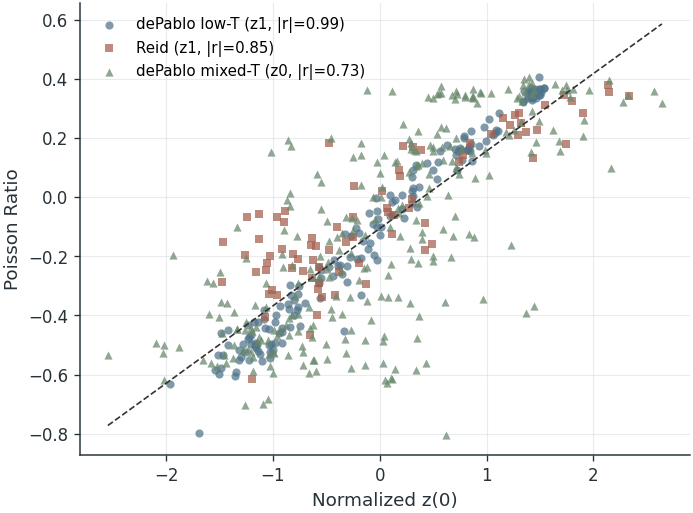

Plot: Normalized latent slope versus Poisson Ratio. Each dataset uses the most correlated latent coordinate for this descriptor type.


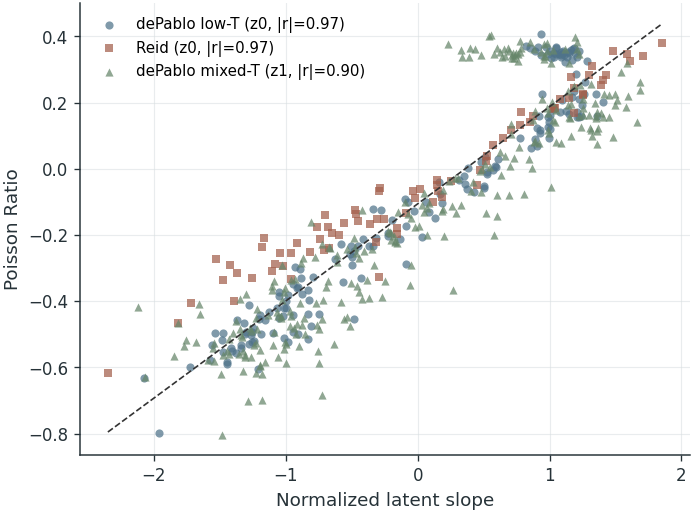

Plot: initial latent coordinate coupling. Each dataset shows raw z0(0) versus raw z1(0), colored by Poisson Ratio.


,case_label,n,z0_z1_pearson_r,z0_pratio_pearson_r,z1_pratio_pearson_r,z0_pratio_corr_r2,z1_pratio_corr_r2
0,dePablo low temperature,179,-0.997,-0.987,0.988,0.974,0.975
2,dePablo mixed temperature,279,0.945,0.729,0.472,0.531,0.223
4,Reid,81,-0.998,0.840,-0.852,0.705,0.725


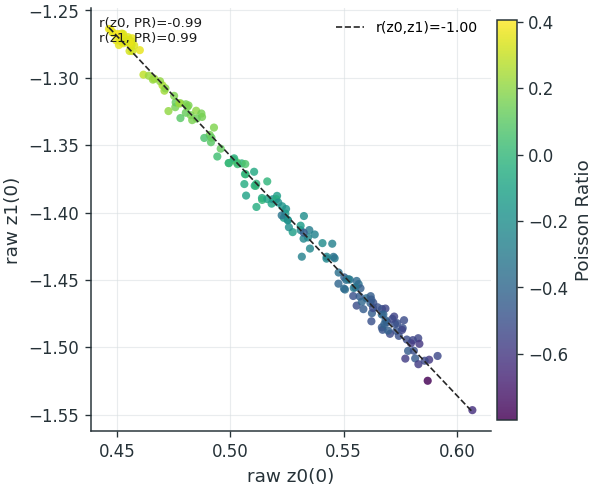

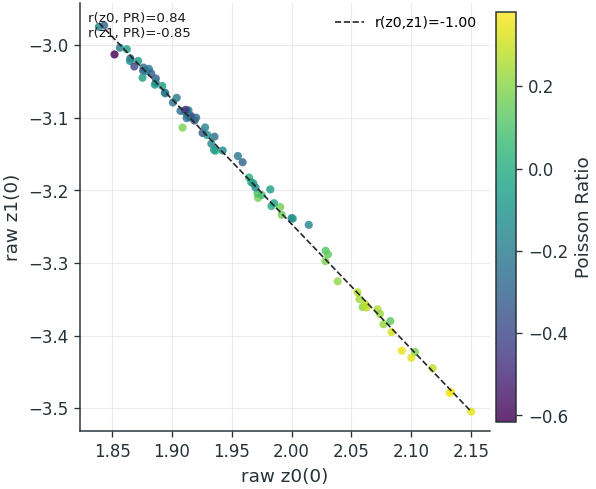

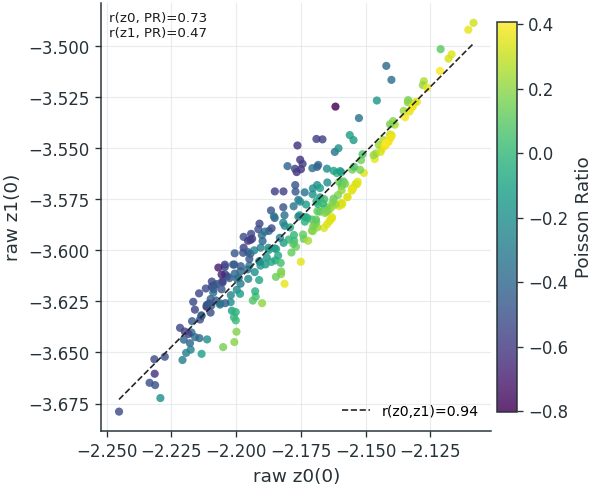

Plot: held-out Poisson Ratio R2 from global latent descriptors and simple global controls.


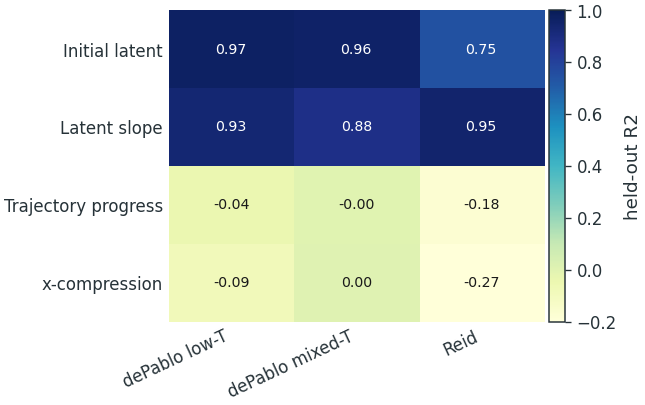

Plot: separate latent traces for the three lowest and three highest Poisson-ratio held-out networks in each dataset and coordinate.


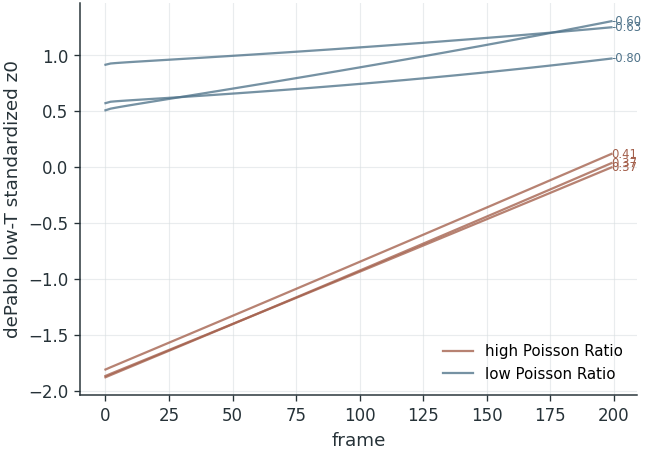

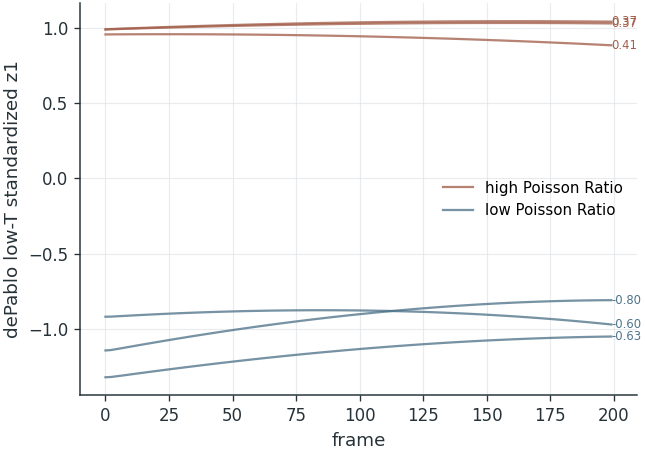

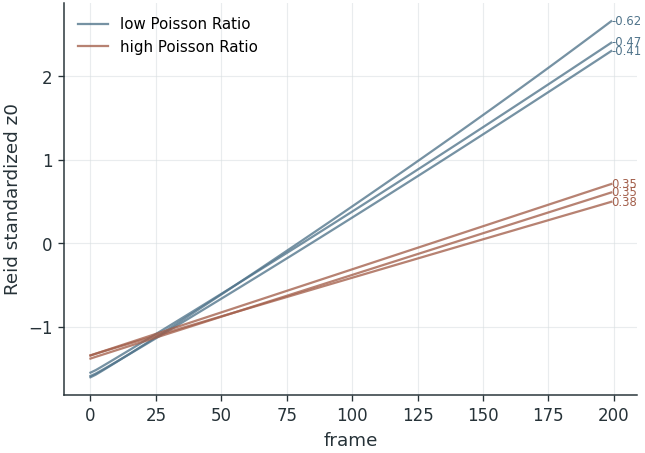

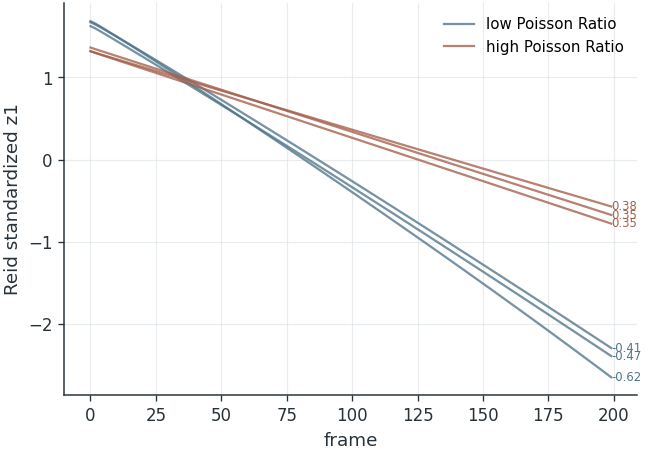

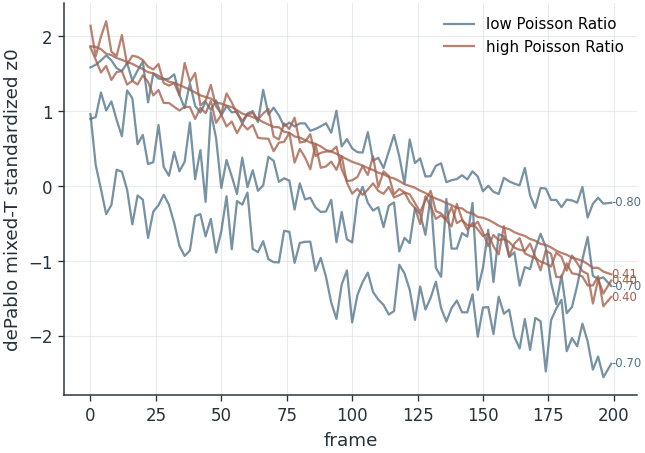

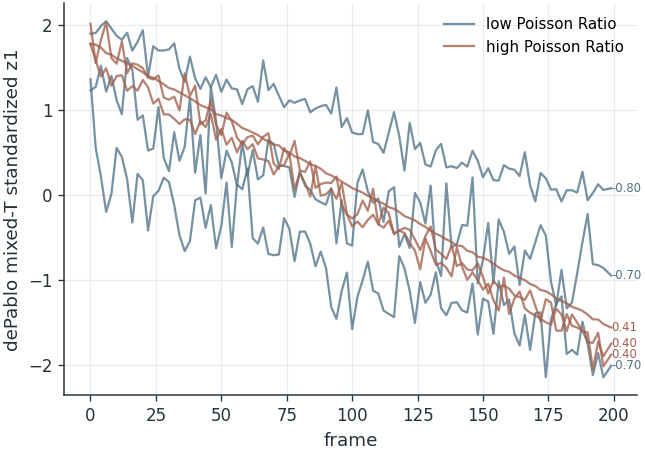

dePablo low temperature: one value per network
dePablo low temperature: mean within-trajectory correlation
Reid: one value per network
Reid: mean within-trajectory correlation
dePablo mixed temperature: one value per network
dePablo mixed temperature: mean within-trajectory correlation


,case,case_label,descriptor,metric,metric_column,pearson_r,n_networks
0,depablo_low_temp,dePablo low temperature,z0_initial,final p-ratio,final_p_ratio,-0.987,179
1,depablo_low_temp,dePablo low temperature,z0_initial,temperature,temperature,NaN,179
2,depablo_low_temp,dePablo low temperature,z1_initial,final p-ratio,final_p_ratio,0.988,179
3,depablo_low_temp,dePablo low temperature,z1_initial,temperature,temperature,NaN,179
4,depablo_low_temp,dePablo low temperature,z0_slope,final p-ratio,final_p_ratio,0.968,179
5,depablo_low_temp,dePablo low temperature,z0_slope,temperature,temperature,NaN,179
6,depablo_low_temp,dePablo low temperature,z1_slope,final p-ratio,final_p_ratio,-0.558,179
7,depablo_low_temp,dePablo low temperature,z1_slope,temperature,temperature,NaN,179
8,reid,Reid,z0_initial,final p-ratio,final_p_ratio,0.840,81
9,reid,Reid,z0_initial,temperature,temperature,NaN,81


,case,case_label,coordinate,metric,metric_column,mean_r,median_r,std_r,n_trajectories
0,depablo_low_temp,dePablo low temperature,z0,RMS displacement,rms_disp,1.000,1.000,0.000,179
1,depablo_low_temp,dePablo low temperature,z0,frame p-ratio,side_cumulative_p_ratio,-0.708,-0.802,0.340,179
2,depablo_low_temp,dePablo low temperature,z0,nonaffinity,nonaffine_rms,1.000,1.000,0.000,179
3,depablo_low_temp,dePablo low temperature,z0,progress,frame_progress,1.000,1.000,0.000,179
4,depablo_low_temp,dePablo low temperature,z0,x strain,side_strain_x,-1.000,-1.000,0.000,179
5,depablo_low_temp,dePablo low temperature,z0,y strain,side_strain_y,-0.174,-0.995,0.976,179
6,depablo_low_temp,dePablo low temperature,z1,RMS displacement,rms_disp,0.436,0.950,0.807,179
7,depablo_low_temp,dePablo low temperature,z1,frame p-ratio,side_cumulative_p_ratio,-0.484,-0.827,0.608,179
8,depablo_low_temp,dePablo low temperature,z1,nonaffinity,nonaffine_rms,0.432,0.946,0.809,179
9,depablo_low_temp,dePablo low temperature,z1,progress,frame_progress,0.437,0.953,0.807,179


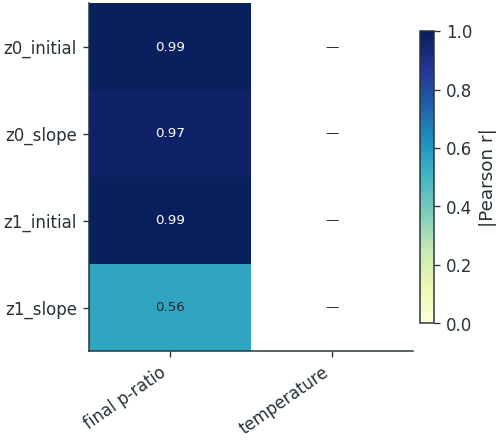

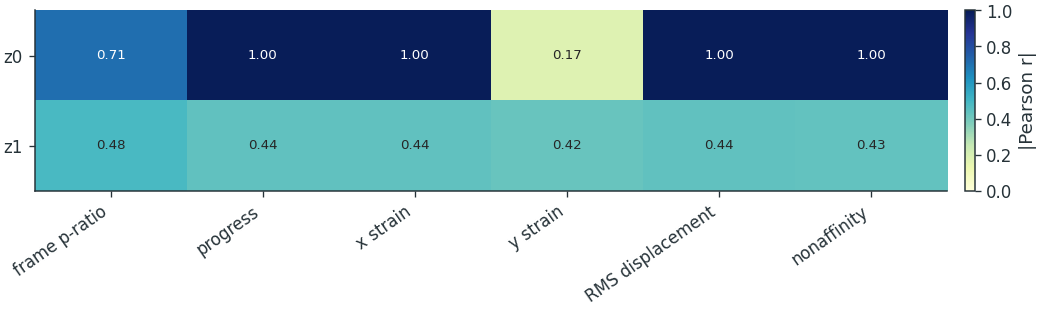

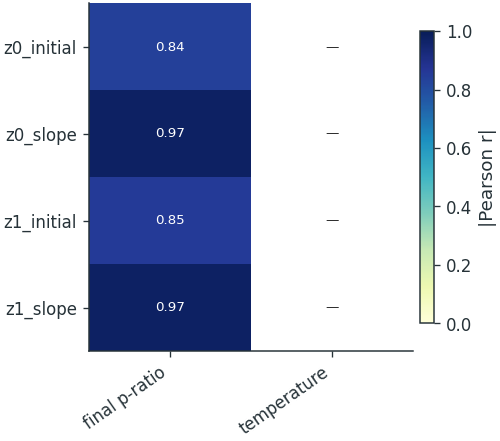

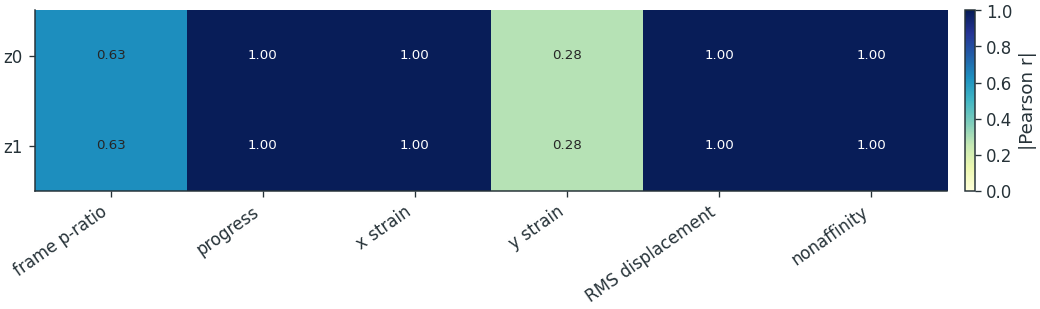

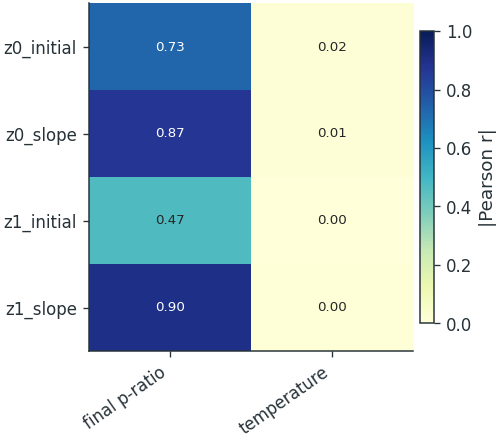

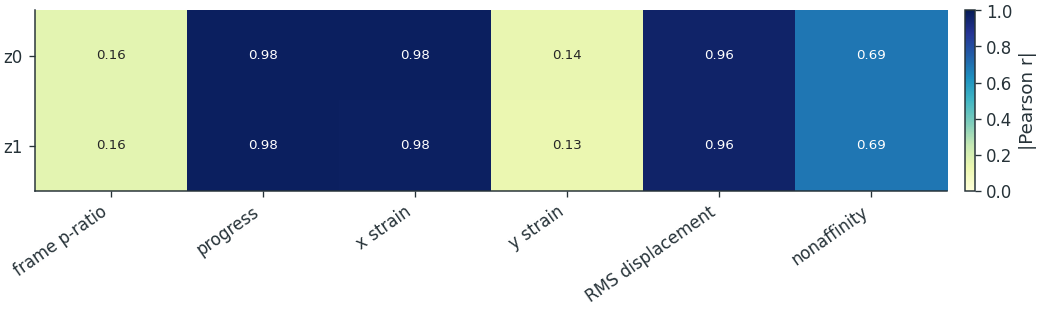

In [25]:
DATASET_STYLE = {
    "depablo_low_temp": {"color": PAPER_COLORS["blue"], "marker": "o", "short": "dePablo low-T"},
    "reid": {"color": PAPER_COLORS["red"], "marker": "s", "short": "Reid"},
    "depablo_mixed_temp": {"color": PAPER_COLORS["green"], "marker": "^", "short": "dePablo mixed-T"},
}

CASE_ORDER = list(CASES)
CASE_LABEL_SHORT = {key: DATASET_STYLE[key]["short"] for key in CASE_ORDER}


def sorted_latent_columns(df: pd.DataFrame, suffix: str | None = None, framewise: bool = False) -> list[str]:
    if framewise:
        return sorted(
            [col for col in df.columns if col.startswith("z") and col[1:].isdigit()],
            key=lambda col: int(col[1:]),
        )
    return sorted(
        [col for col in df.columns if col.startswith("z") and (suffix is None or col.endswith(suffix))],
        key=lambda col: int(col[1:].split("_")[0]),
    )


def best_correlated_column(df: pd.DataFrame, feature_cols: list[str], target_col: str) -> tuple[str | None, float]:
    correlations = {
        col: pearson_r(df[col], df[target_col])
        for col in feature_cols
        if col in df and target_col in df
    }
    col = max(correlations, key=lambda key: abs(correlations[key]))
    return col, correlations[col]


def normalized_signed(values, reference_r: float | None = None) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    scale = np.nanstd(values)
    out = (values - np.nanmean(values)) / scale
    if reference_r is not None and np.isfinite(reference_r) and reference_r < 0:
        out = -out
    return out


def save_current_figure(fig, stem: str) -> None:
    fig.savefig(OUTPUT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{stem}.pdf", bbox_inches="tight")


def plot_global_descriptor_scatter(descriptor_df: pd.DataFrame, *, suffix: str, xlabel: str, output_stem: str) -> None:
    print(f"Plot: {xlabel} versus Poisson Ratio. Each dataset uses the most correlated latent coordinate for this descriptor type.")
    fig, ax = plt.subplots(figsize=(5.8, 4.3), constrained_layout=True)
    combined = []
    for case_key in CASE_ORDER:
        traj = descriptor_df[(descriptor_df["case"].eq(case_key)) & (descriptor_df["split"].eq("test"))].copy()
        feature_cols = sorted_latent_columns(traj, suffix=suffix)
        valid = traj[["final_p_ratio", *feature_cols]].replace([np.inf, -np.inf], np.nan).dropna()
        z_col, r = best_correlated_column(valid, feature_cols, "final_p_ratio")
        x = normalized_signed(valid[z_col].to_numpy(float), r)
        y = valid["final_p_ratio"].to_numpy(float)
        style = DATASET_STYLE[case_key]
        ax.scatter(
            x,
            y,
            s=24,
            color=style["color"],
            marker=style["marker"],
            alpha=0.72,
            linewidth=0,
            label=f"{style['short']} ({z_col.replace(suffix, '')}, |r|={abs(r):.2f})",
        )
        combined.append(pd.DataFrame({"x": x, "y": y}))
    points = pd.concat(combined, ignore_index=True)
    slope, intercept = np.polyfit(points["x"], points["y"], deg=1)
    xx = np.linspace(float(points["x"].min()), float(points["x"].max()), 120)
    ax.plot(xx, slope * xx + intercept, color="0.20", lw=1.0, ls="--")
    style_axes(ax, xlabel=xlabel, ylabel="Poisson Ratio", legend=True)
    plt.show()
    save_current_figure(fig, output_stem)


def initial_latent_coordinate_correlation_table(descriptor_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (case_key, split), group in descriptor_df.groupby(["case", "split"]):
        initial_cols = sorted_latent_columns(group, suffix="_initial")[:2]
        z0_col, z1_col = initial_cols
        valid = group[[z0_col, z1_col, "final_p_ratio"]].replace([np.inf, -np.inf], np.nan).dropna()
        if valid.empty:
            raise ValueError(f"No finite initial latent rows for {case_key} {split}.")
        rows.append(
            {
                "case": case_key,
                "case_label": group["case_label"].iloc[0],
                "split": split,
                "n": int(len(valid)),
                "z0_column": z0_col,
                "z1_column": z1_col,
                "z0_z1_pearson_r": pearson_r(valid[z0_col], valid[z1_col]),
                "z0_pratio_pearson_r": pearson_r(valid[z0_col], valid["final_p_ratio"]),
                "z1_pratio_pearson_r": pearson_r(valid[z1_col], valid["final_p_ratio"]),
            }
        )
    out = pd.DataFrame(rows)
    out["z0_pratio_corr_r2"] = out["z0_pratio_pearson_r"] ** 2
    out["z1_pratio_corr_r2"] = out["z1_pratio_pearson_r"] ** 2
    return out


def plot_initial_latent_coordinate_coupling(descriptor_df: pd.DataFrame) -> None:
    print("Plot: initial latent coordinate coupling. Each dataset shows raw z0(0) versus raw z1(0), colored by Poisson Ratio.")
    corr_table = initial_latent_coordinate_correlation_table(descriptor_df)
    corr_table.to_csv(OUTPUT_DIR / "initial_latent_coordinate_correlations.csv", index=False)
    display(
        corr_table[corr_table["split"].eq("test")][
            [
                "case_label",
                "n",
                "z0_z1_pearson_r",
                "z0_pratio_pearson_r",
                "z1_pratio_pearson_r",
                "z0_pratio_corr_r2",
                "z1_pratio_corr_r2",
            ]
        ].round(3)
    )

    for case_key in CASE_ORDER:
        group = descriptor_df[(descriptor_df["case"].eq(case_key)) & (descriptor_df["split"].eq("test"))].copy()
        initial_cols = sorted_latent_columns(group, suffix="_initial")[:2]
        z0_col, z1_col = initial_cols
        valid = group[[z0_col, z1_col, "final_p_ratio"]].replace([np.inf, -np.inf], np.nan).dropna()
        if valid.empty:
            raise ValueError(f"No finite initial latent rows for {case_key} test.")
        r_z = pearson_r(valid[z0_col], valid[z1_col])
        r0 = pearson_r(valid[z0_col], valid["final_p_ratio"])
        r1 = pearson_r(valid[z1_col], valid["final_p_ratio"])
        fig, ax = plt.subplots(figsize=(5.0, 4.1), constrained_layout=True)
        points = ax.scatter(
            valid[z0_col],
            valid[z1_col],
            c=valid["final_p_ratio"],
            cmap="viridis",
            s=24,
            alpha=0.82,
            linewidth=0,
        )
        slope, intercept = np.polyfit(valid[z0_col], valid[z1_col], deg=1)
        xx = np.linspace(float(valid[z0_col].min()), float(valid[z0_col].max()), 120)
        ax.plot(xx, slope * xx + intercept, color="0.15", lw=1.0, ls="--", label=f"r(z0,z1)={r_z:.2f}")
        ax.legend(frameon=False, loc="best", fontsize=8.5)
        cb = fig.colorbar(points, ax=ax, pad=0.015, fraction=0.050)
        cb.set_label("Poisson Ratio")
        style_axes(
            ax,
            xlabel=f"raw {z0_col.replace('_initial', '')}(0)",
            ylabel=f"raw {z1_col.replace('_initial', '')}(0)",
        )
        ax.text(
            0.02,
            0.98,
            f"r(z0, PR)={r0:.2f}\nr(z1, PR)={r1:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.0,
            color="0.10",
        )
        plt.show()
        save_current_figure(fig, f"paper_05_initial_latent_coordinate_coupling_{case_key}")


def plot_global_descriptor_r2_heatmap(readout_summary: pd.DataFrame) -> None:
    print("Plot: held-out Poisson Ratio R2 from global latent descriptors and simple global controls.")
    compact = readout_summary[readout_summary["feature_set"].isin([
        "initial latent",
        "latent slope",
        "protocol/frame index",
        "x-compression only",
    ])].copy()
    compact["method"] = compact["feature_set"].map({
        "initial latent": "Initial latent",
        "latent slope": "Latent slope",
        "protocol/frame index": "Trajectory progress",
        "x-compression only": "x-compression",
    })
    method_order = ["Initial latent", "Latent slope", "Trajectory progress", "x-compression"]
    compact["method"] = pd.Categorical(compact["method"], categories=method_order, ordered=True)
    table = (
        compact.pivot_table(index="method", columns="case", values="r2", aggfunc="first", observed=False)
        .reindex(method_order)
        .rename(columns=CASE_LABEL_SHORT)
    )
    table.to_csv(OUTPUT_DIR / "global_descriptor_r2_table.csv")
    values = table.to_numpy(float)
    fig, ax = plt.subplots(figsize=(5.4, 3.4), constrained_layout=True)
    image = ax.imshow(values, cmap="YlGnBu", vmin=-0.2, vmax=1.0, aspect="auto")
    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels(table.columns, rotation=25, ha="right")
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False, which="both")
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            value = values[row, col]
            label = f"{value:.2f}"
            color = "white" if value > 0.72 else "0.10"
            ax.text(col, row, label, ha="center", va="center", color=color, fontsize=8.5)
    cb = fig.colorbar(image, ax=ax, pad=0.015, fraction=0.050)
    cb.set_label("held-out R2")
    plt.show()
    save_current_figure(fig, "paper_05_global_descriptor_r2_heatmap")


def plot_high_low_pratio_trace_images(descriptor_df: pd.DataFrame, frame_df: pd.DataFrame, *, n_each: int = 3) -> None:
    print("Plot: separate latent traces for the three lowest and three highest Poisson-ratio held-out networks in each dataset and coordinate.")
    test_descriptors = descriptor_df[descriptor_df["split"].eq("test")].copy()
    test_frames = frame_df[frame_df["split"].eq("test")].copy()
    selection_rows = []
    group_style = {
        "low Poisson Ratio": {"color": PAPER_COLORS["blue"], "alpha": 0.78},
        "high Poisson Ratio": {"color": PAPER_COLORS["red"], "alpha": 0.78},
    }
    for case_key in CASE_ORDER:
        case_desc = test_descriptors[test_descriptors["case"].eq(case_key)].copy()
        case_frames = test_frames[test_frames["case"].eq(case_key)].copy()
        z_cols = sorted_latent_columns(case_frames, framewise=True)[:2]
        low = case_desc.sort_values("final_p_ratio", ascending=True).head(int(n_each)).copy()
        high = case_desc.sort_values("final_p_ratio", ascending=False).head(int(n_each)).copy()
        selected = pd.concat(
            [low.assign(group="low Poisson Ratio"), high.assign(group="high Poisson Ratio")],
            ignore_index=True,
        )
        selected["case"] = case_key
        selection_rows.append(selected)
        plot_frames = case_frames.merge(
            selected[["sim_idx", "group", "final_p_ratio"]],
            on="sim_idx",
            how="inner",
            suffixes=("", "_selected"),
        )
        for z_col in z_cols:
            plot_frames[f"{z_col}_std"] = normalized_signed(plot_frames[z_col].to_numpy(float), None)
            fig, ax = plt.subplots(figsize=(5.4, 3.8), constrained_layout=True)
            for group_label, group_df in plot_frames.groupby("group", sort=False):
                style = group_style[group_label]
                for idx, (sim_idx, trace) in enumerate(group_df.groupby("sim_idx")):
                    trace = trace.sort_values("frame_idx")
                    pr = float(trace["final_p_ratio"].iloc[0])
                    ax.plot(
                        trace["frame_idx"],
                        trace[f"{z_col}_std"],
                        color=style["color"],
                        alpha=style["alpha"],
                        lw=1.35,
                        label=group_label if idx == 0 else None,
                    )
                    ax.text(
                        float(trace["frame_idx"].iloc[-1]),
                        float(trace[f"{z_col}_std"].iloc[-1]),
                        f"{pr:.2f}",
                        color=style["color"],
                        fontsize=7.0,
                        ha="left",
                        va="center",
                    )
            style_axes(ax, xlabel="frame", ylabel=f"{CASE_LABEL_SHORT[case_key]} standardized {z_col}", legend=True)
            plt.show()
            save_current_figure(fig, f"paper_05_high_low_pratio_{case_key}_{z_col}_traces")
    pd.concat(selection_rows, ignore_index=True).to_csv(OUTPUT_DIR / "high_low_pratio_trace_selection.csv", index=False)


plot_global_descriptor_scatter(descriptor_df, suffix="_initial", xlabel="Normalized z(0)", output_stem="paper_05_global_initial_latent_vs_pratio")
plot_global_descriptor_scatter(descriptor_df, suffix="_slope", xlabel="Normalized latent slope", output_stem="paper_05_global_latent_slope_vs_pratio")
plot_initial_latent_coordinate_coupling(descriptor_df)
plot_global_descriptor_r2_heatmap(readout_summary)
plot_high_low_pratio_trace_images(descriptor_df, frame_df)

# Separate one-value-per-network descriptors from within-trajectory dynamics.
import importlib
import lss.latent.analysis as latent_analysis
latent_analysis = importlib.reload(latent_analysis)
network_level_latent_correlations = latent_analysis.network_level_latent_correlations
per_trajectory_latent_correlations = latent_analysis.per_trajectory_latent_correlations
plot_correlation_heatmap = latent_analysis.plot_correlation_heatmap
network_metrics = {'final p-ratio': 'final_p_ratio', 'temperature': 'temperature'}
dynamic_metrics = {
    'frame p-ratio': 'side_cumulative_p_ratio',
    'progress': 'frame_progress', 'x strain': 'side_strain_x', 'y strain': 'side_strain_y',
    'RMS displacement': 'rms_disp', 'nonaffinity': 'nonaffine_rms',
}
network_parts, trajectory_parts, trajectory_summary_parts = [], [], []
for case_key, descriptor_group in descriptor_df.query("split == 'test'").groupby('case', sort=False):
    label = descriptor_group.case_label.iloc[0]
    network_table = network_level_latent_correlations(descriptor_group, metric_columns=network_metrics)
    network_table.insert(0, 'case', case_key); network_table.insert(1, 'case_label', label)
    network_parts.append(network_table)
    fig = plot_correlation_heatmap(network_table, row='descriptor', column='metric', value='pearson_r', column_order=list(network_metrics), title=f'{label}: one value per network')
    save_current_figure(fig, f'paper_05_network_level_latent_correlations_{case_key}')
    frame_group = frame_df.query("split == 'test' and case == @case_key")
    per_trajectory, trajectory_summary = per_trajectory_latent_correlations(frame_group, metric_columns=dynamic_metrics)
    per_trajectory.insert(0, 'case', case_key); per_trajectory.insert(1, 'case_label', label)
    trajectory_summary.insert(0, 'case', case_key); trajectory_summary.insert(1, 'case_label', label)
    trajectory_parts.append(per_trajectory); trajectory_summary_parts.append(trajectory_summary)
    fig = plot_correlation_heatmap(trajectory_summary, row='coordinate', column='metric', value='mean_r', column_order=list(dynamic_metrics), title=f'{label}: mean within-trajectory correlation')
    save_current_figure(fig, f'paper_05_within_trajectory_latent_correlations_{case_key}')
network_correlations = pd.concat(network_parts, ignore_index=True)
trajectory_correlations = pd.concat(trajectory_parts, ignore_index=True)
trajectory_correlation_summary = pd.concat(trajectory_summary_parts, ignore_index=True)
network_correlations.to_csv(OUTPUT_DIR/'network_level_latent_correlations.csv', index=False)
trajectory_correlations.to_csv(OUTPUT_DIR/'within_trajectory_latent_correlations_per_network.csv', index=False)
trajectory_correlation_summary.to_csv(OUTPUT_DIR/'within_trajectory_latent_correlations_summary.csv', index=False)
display(network_correlations.round(3)); display(trajectory_correlation_summary.round(3))


## Supplemental Mixed-Temperature Fluctuation Diagnostic


Plot: mixed-temperature z0 traces; one held-out trajectory per temperature


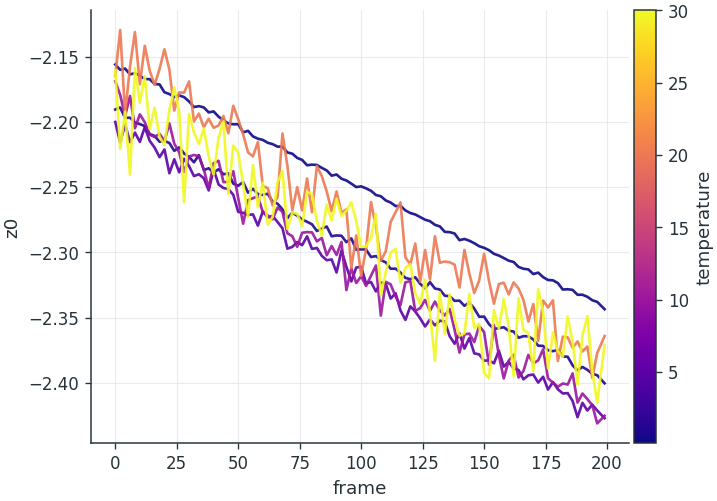

Plot: mixed-temperature z1 traces; one held-out trajectory per temperature


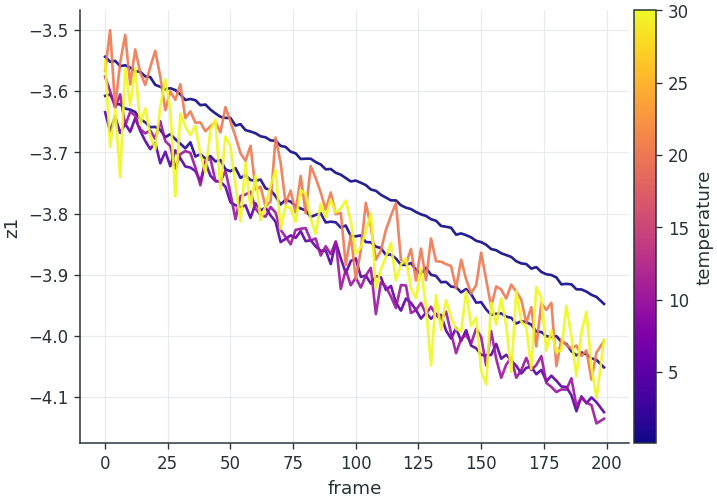

Plot: mixed-temperature thermal latent fluctuation for z0_detrended_std; Pearson r=0.89


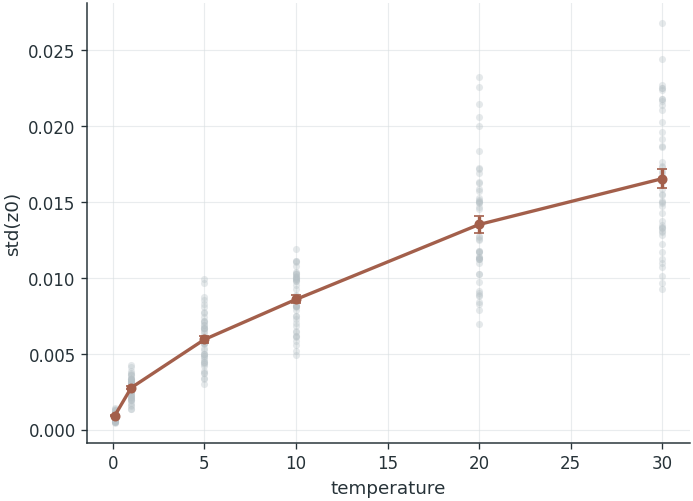

Plot: mixed-temperature thermal latent fluctuation for z1_detrended_std; Pearson r=0.88


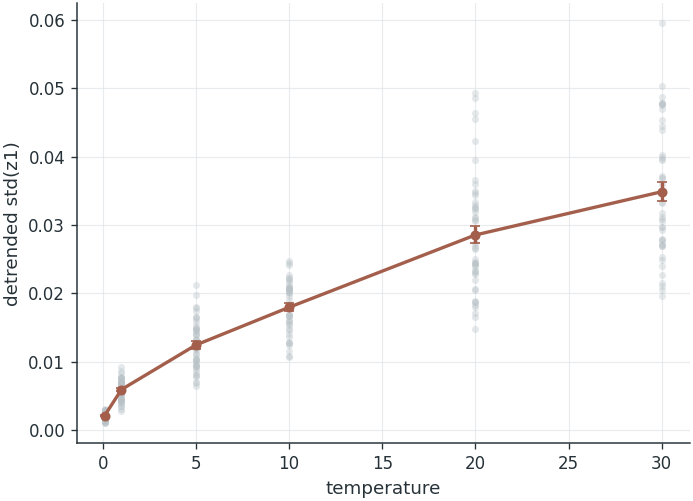

In [26]:
def plot_mixed_temperature_fluctuations_separate(descriptor_df: pd.DataFrame, frame_df: pd.DataFrame) -> None:
    case_key = "depablo_mixed_temp"
    traj = descriptor_df[(descriptor_df["case"].eq(case_key)) & (descriptor_df["split"].eq("test"))].copy()
    frames = frame_df[(frame_df["case"].eq(case_key)) & (frame_df["split"].eq("test"))].copy()
    temperatures = sorted(t for t in traj["temperature"].dropna().unique())
    cmap = plt.cm.plasma
    norm = Normalize(vmin=min(temperatures), vmax=max(temperatures))
    selected = []
    for temperature in temperatures:
        candidates = traj[traj["temperature"].eq(temperature)].sort_values("final_p_ratio")
        selected.append(int(candidates.iloc[len(candidates) // 2]["sim_idx"]))

    for z_col in ["z0", "z1"]:
        print(f"Plot: mixed-temperature {z_col} traces; one held-out trajectory per temperature")
        fig, ax = plt.subplots(figsize=(6.0, 4.2), constrained_layout=True)
        for sim_idx in selected:
            group = frames[frames["sim_idx"].eq(sim_idx)].sort_values("frame_idx")
            temperature = float(group["temperature"].iloc[0])
            ax.plot(group["frame_idx"], group[z_col], color=cmap(norm(temperature)), lw=1.6, alpha=0.9)
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        cb = fig.colorbar(sm, ax=ax, pad=0.01)
        cb.set_label("temperature")
        style_axes(ax, xlabel="frame", ylabel=z_col)
        plt.show()

    for metric, ylabel in [("z0_detrended_std", "std(z0)"), ("z1_detrended_std", "detrended std(z1)")]:
        r = pearson_r(traj["temperature"], traj[metric])
        print(f"Plot: mixed-temperature thermal latent fluctuation for {metric}; Pearson r={r:.2f}")
        fig, ax = plt.subplots(figsize=(5.8, 4.2), constrained_layout=True)
        ax.scatter(traj["temperature"], traj[metric], s=18, color=PAPER_COLORS["light"], alpha=0.35, linewidth=0)
        summary = traj.groupby("temperature", as_index=False).agg(mean=(metric, "mean"), sem=(metric, "sem"))
        ax.errorbar(summary["temperature"], summary["mean"], yerr=summary["sem"], marker="o", lw=2, capsize=3, color=PAPER_COLORS["red"])
        style_axes(ax, xlabel="temperature", ylabel=ylabel)
        plt.show()


plot_mixed_temperature_fluctuations_separate(descriptor_df, frame_df)


## Latent capacity: p-ratio reconstruction versus frame

This matched sweep repeats the AE-only experiment for latent dimensions 1–6. Each panel shows held-out p-ratio $R^2$ when the AE independently encodes and decodes the observed displacement at that frame. Dimension-specific checkpoints are cached under `capacity_sweep`; set `CAPACITY_FORCE_TRAIN=True` only to overwrite them.

In [ ]:
from lss.latent.experiment import evaluate_autoencoder_reconstruction_horizons

CAPACITY_DIMS = list(range(1, 7))
CAPACITY_STEPS = [10, 25, 50, 75, 99, 125, 150, 199]
CAPACITY_FORCE_TRAIN = False

def build_capacity_case(case_key, case_spec, latent_dim):
    seed = BASE_SEED + 101 * (list(CASES).index(case_key) + 1)
    cfg, source = build_case_config(case_key, case_spec, seed=seed)
    cache_dir = OUTPUT_DIR/'capacity_sweep'/case_key
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache = cache_dir/f'ae_{AUTOENCODER_MODEL}_cv{latent_dim}_train{TRAIN_COUNT}_frames{AE_TRAIN_FRAMES}_seed{seed}.pt'
    cfg.update(latent_dim=latent_dim, cache_path=str(cache), force_train=CAPACITY_FORCE_TRAIN)
    source.update(latent_dim=latent_dim, label=f"{case_spec['label']} AE CV{latent_dim}, train={TRAIN_COUNT}")
    return seed, cfg, source

capacity_parts = []
for case_key, case_spec in CASES.items():
    for latent_dim in CAPACITY_DIMS:
        seed, dim_cfg, dim_source = build_capacity_case(case_key, case_spec, latent_dim)
        seed_everything(seed)
        dim_result = run_latent_experiment(dim_source, dim_cfg, device=DEVICE)
        _, stats = evaluate_autoencoder_reconstruction_horizons(
            dim_result['ae'], dim_result['test_data'], cfg=dim_result['params'],
            normalizers=dim_result['normalizers'], dataset=case_spec['label'],
            split_name='test', rollout_steps=CAPACITY_STEPS, device=DEVICE,
        )
        stats['case'] = case_key; stats['latent_dim'] = latent_dim
        capacity_parts.append(stats)

capacity_r2 = pd.concat(capacity_parts, ignore_index=True)
capacity_r2.to_csv(OUTPUT_DIR/'ae_pratio_r2_by_step_and_latent_dim.csv', index=False)
print('AE reconstruction p-ratio R² versus frame and latent dimension; panels are de Pablo, Reid, and mixed-temperature de Pablo.')
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.4), sharex=True, sharey=False, constrained_layout=True)
for ax, (case_key, case_spec) in zip(axes.flat, CASES.items()):
    subset = capacity_r2[capacity_r2.case.eq(case_key)]
    for latent_dim, group in subset.groupby('latent_dim'):
        group = group.sort_values('rollout_steps')
        ax.plot(group.rollout_steps, group.p_ratio_r2, marker='o', ms=3.5, lw=1.5, label=f'{latent_dim}D')
    ax.axhline(0, color='black', lw=.8)
    ax.text(.03, .96, case_spec['label'], transform=ax.transAxes, ha='left', va='top')
    style_axes(ax, xlabel='observed frame reconstructed by AE', ylabel='p-ratio $R^2$', legend=True)
fig.savefig(OUTPUT_DIR/'ae_pratio_r2_by_step_and_latent_dim.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR/'ae_pratio_r2_by_step_and_latent_dim.pdf', bbox_inches='tight')
plt.show()

loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05_paper_autoencoder_cvs/capacity_sweep/depablo_low_temp/ae_attention_cv1_train1_frames100_seed6646.pt


loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05_paper_autoencoder_cvs/capacity_sweep/depablo_low_temp/ae_attention_cv2_train1_frames100_seed6646.pt
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05_paper_autoencoder_cvs/capacity_sweep/depablo_low_temp/ae_attention_cv3_train1_frames100_seed6646.pt


## Short Paper Narrative

The main figures now separate two latent-space claims. First, global per-network descriptors such as `z(0)` and latent slope predict Poisson Ratio on held-out networks while simple trajectory-progress and x-compression controls do not. Second, the full latent trajectory carries dynamical deformation information: framewise latent coordinates correlate with x-deformation, y-response, displacement, and nonaffinity in ways that are not identical across the two CVs. High/low Poisson-ratio trace panels provide concrete examples of how auxetic and non-auxetic networks occupy different latent trajectories.
